# Stage 4 — DiCE-ML Counterfactual Açıklamalar

**Amaç:** Reddedilen başvuru sahiplerine "şu değişiklikleri yapsaydın kredi onaylanırdı" türünde  
somut, uygulanabilir geri bildirim üretmek.

**Yöntem:** DiCE-ML (Diverse Counterfactual Explanations) — eğitilmiş XGBoost modeli üzerinde  
rastgele arama ile alternatif senaryolar bulur.

**SHAP vs DiCE farkı:**
- SHAP (Notebook 03): "Model neden bu kararı verdi?" → geçmişe dönük açıklama  
- DiCE (bu notebook): "Karar nasıl değişirdi?" → geleceğe dönük öneri

**Pipeline'daki yeri:**
```
Stage 1 (IF) → Stage 2 (XGBoost) → Stage 3 (Faiz) → Stage 4 (DiCE)
                      ↑
              eğitilmiş model bu notebook'a girdi
```

**Actionable features** (başvuru sahibinin değiştirebileceği özellikler):
- `LoanAmount` — daha düşük kredi talep et
- `HasCoSigner` — kefil ekle (0=Hayır → 1=Evet)
- `Income` — gelir belgesi güçlendir

**Sabit tutulan özellikler:** Age, CreditScore, Education, MaritalStatus vb.

## 1. Kütüphaneler & Sabitler

In [1]:
import importlib.metadata
import json
import warnings
from pathlib import Path

import dice_ml
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

ROOT       = Path('..').resolve()
MODEL_DIR  = ROOT / 'models'
DATA_DIR   = ROOT / 'data' / 'interim'
FIG_DIR    = ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

NUMERICAL_COLS_ORIGINAL = [
    'Age', 'Income', 'LoanAmount', 'CreditScore',
    'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
]
NUMERICAL_COLS_ALL = NUMERICAL_COLS_ORIGINAL + [
    'LoanToIncome', 'PaymentToIncome', 'CreditAgePerLine', 'TotalDebtBurden',
]
CATEGORICAL_COLS = [
    'Education', 'EmploymentType', 'MaritalStatus',
    'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
]
ACTIONABLE = ['LoanAmount', 'HasCoSigner', 'Income']

print('DiCE-ML sürümü:', importlib.metadata.version('dice-ml'))
print('ROOT:', ROOT)

DiCE-ML sürümü: 0.12
ROOT: C:\Users\nesli\Desktop\LoanGuard


## 2. Artifact'ları Yükle

In [2]:
label_encoders = joblib.load(MODEL_DIR / 'label_encoders.joblib')
scaler         = joblib.load(MODEL_DIR / 'scaler.joblib')
xgb_model      = joblib.load(MODEL_DIR / 'xgboost_risk_model.joblib')

with open(MODEL_DIR / 'xgboost_metadata.json', encoding='utf-8') as f:
    meta = json.load(f)

THRESHOLD     = meta['optimal_threshold']
FEATURE_NAMES = meta['feature_names']

print(f'Optimal threshold : {THRESHOLD:.4f}')
print(f'Feature sayısı    : {len(FEATURE_NAMES)}')
print(f'Encoder sayısı    : {len(label_encoders)}')

Optimal threshold : 0.4885
Feature sayısı    : 20
Encoder sayısı    : 7


## 3. Background Dataset

DiCE'ın rastgele arama yapabilmesi için feature uzayını anlaması gerekir.  
Bunun için `loans_cleaned.csv` kullanılır (label-encoded, pre-ratio, pre-scale).  
5.000 satırlık örneklem yeterli — tam veri gereksiz yük oluşturur.

In [3]:
bg = pd.read_csv(DATA_DIR / 'loans_cleaned.csv')
bg = bg.sample(n=5000, random_state=SEED).reset_index(drop=True)

print(f'Background dataset: {bg.shape[0]:,} satır × {bg.shape[1]} sütun')
print(f'Temerrüt oranı    : {bg["Default"].mean():.1%}')
bg.head(3)

Background dataset: 5,000 satır × 17 sütun
Temerrüt oranı    : 11.1%


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,55,112656,92393,581,113,2,23.54,36,0.15,3,2,2,1,1,3,0,0
1,56,91569,131575,641,54,1,15.19,12,0.43,1,1,0,1,1,2,1,0
2,26,78169,75417,569,105,3,18.02,12,0.29,2,1,1,1,1,2,1,0


## 4. Model Wrapper & DiCE Kurulumu

DiCE, aday counterfactual'ları değerlendirmek için modeli çağırır.  
Wrapper; rasyo hesaplama → ölçekleme → XGBoost tahminini bir arada yapar.

Background dataset `loans_cleaned.csv` formatında (ratio yok, scale yok).  
Wrapper, DiCE'ın ürettiği bu formattaki verileri gerçek model input'una dönüştürür.

In [4]:
def add_ratios(df: pd.DataFrame) -> pd.DataFrame:
    """Annuity-based financial ratios (02b_feature_engineering formülü)."""
    df = df.copy()
    r  = df['InterestRate'] / 1200
    n  = df['LoanTerm']
    P  = df['LoanAmount']
    mi = df['Income'] / 12
    pmt = np.where(
        r < 1e-10,
        P / np.maximum(n, 1),
        P * r / (1 - (1 + r) ** (-n)),
    )
    df['LoanToIncome']     = P  / np.maximum(df['Income'], 1)
    df['PaymentToIncome']  = pmt / np.maximum(mi, 1)
    df['CreditAgePerLine'] = df['MonthsEmployed'] / (df['NumCreditLines'] + 1)
    df['TotalDebtBurden']  = (pmt * n) / np.maximum(df['Income'], 1)
    return df


class PipelineWrapper:
    """sklearn-compatible wrapper: pre-encoded data → ratios → scale → predict."""

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= THRESHOLD).astype(int)

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        X = X.copy()
        # DiCE categorical columns'ı object/category dtype yapıyor;
        # XGBoost 2.x bunu reddeder — hepsini float'a çevir.
        for col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')
        X = add_ratios(X)
        X[NUMERICAL_COLS_ALL] = scaler.transform(X[NUMERICAL_COLS_ALL])
        return xgb_model.predict_proba(X[FEATURE_NAMES])


# DiCE Data — tüm feature'lar loans_cleaned.csv'de zaten integer (label-encoded).
# Hepsini continuous olarak tanımla; random method için categorical/continuous
# ayrımı anlam taşımaz, XGBoost dtype hatasını da engeller.
ALL_FEATURE_COLS = [c for c in bg.columns if c != 'Default']

d = dice_ml.Data(
    dataframe           = bg,
    continuous_features = ALL_FEATURE_COLS,
    outcome_name        = 'Default',
)

m = dice_ml.Model(
    model      = PipelineWrapper(),
    backend    = 'sklearn',
    model_type = 'classifier',
)

exp = dice_ml.Dice(d, m, method='random')
print('DiCE kurulumu tamamlandı.')

DiCE kurulumu tamamlandı.


## 5. Örnek 1 — Reddedilen Başvuru: Yüksek Riskli Mehmet

Yüksek borç yükü ve düşük kredi skoru nedeniyle reddedilen bir profil.

In [5]:
# Profil: label-encoded (02_preprocessing ile aynı format)
# Education: Bachelor's=0, EmploymentType: Full-time=0, MaritalStatus: Single=2
# HasMortgage: No=0, HasDependents: Yes=1, LoanPurpose: Home=3, HasCoSigner: No=0
mehmet = {
    'Age': 38, 'Income': 42000, 'LoanAmount': 95000, 'CreditScore': 540,
    'MonthsEmployed': 24, 'NumCreditLines': 5, 'InterestRate': 18.5,
    'LoanTerm': 60, 'DTIRatio': 0.62,
    'Education': 0, 'EmploymentType': 0, 'MaritalStatus': 2,
    'HasMortgage': 0, 'HasDependents': 1, 'LoanPurpose': 3, 'HasCoSigner': 0,
}

mehmet_df = pd.DataFrame([mehmet])

# Risk skorunu kontrol et
mehmet_ready = add_ratios(mehmet_df).copy()
mehmet_ready[NUMERICAL_COLS_ALL] = scaler.transform(mehmet_ready[NUMERICAL_COLS_ALL])
mehmet_score = xgb_model.predict_proba(mehmet_ready[FEATURE_NAMES])[0, 1]
karar = 'REDDEDİLDİ' if mehmet_score >= THRESHOLD else 'ONAYLI'

print(f'Risk skoru : {mehmet_score:.4f}')
print(f'Karar      : {karar}  (eşik={THRESHOLD:.4f})')

Risk skoru : 0.6771
Karar      : REDDEDİLDİ  (eşik=0.4885)


In [6]:
cf1 = exp.generate_counterfactuals(
    mehmet_df,
    total_CFs       = 3,
    desired_class   = 0,           # Default=0 → onaylı
    features_to_vary = ACTIONABLE,
    random_seed     = SEED,
)
cf1.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  2.45it/s]

Query instance (original outcome : 1)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,38,42000,95000,540,24,5,18.5,60,0.62,0,0,2,0,1,3,0,1



Diverse Counterfactual set (new outcome: 0)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0,0.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0,0.0
2,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0,0.0


## 6. Örnek 2 — Reddedilen Başvuru: Sınırda Ayşe

Risk skoru eşiğe yakın — küçük değişiklikler yeterli olabilir.

In [7]:
ayse = {
    'Age': 29, 'Income': 55000, 'LoanAmount': 70000, 'CreditScore': 590,
    'MonthsEmployed': 36, 'NumCreditLines': 3, 'InterestRate': 14.2,
    'LoanTerm': 48, 'DTIRatio': 0.51,
    'Education': 2, 'EmploymentType': 0, 'MaritalStatus': 1,
    'HasMortgage': 0, 'HasDependents': 0, 'LoanPurpose': 0, 'HasCoSigner': 0,
}

ayse_df = pd.DataFrame([ayse])
ayse_ready = add_ratios(ayse_df).copy()
ayse_ready[NUMERICAL_COLS_ALL] = scaler.transform(ayse_ready[NUMERICAL_COLS_ALL])
ayse_score = xgb_model.predict_proba(ayse_ready[FEATURE_NAMES])[0, 1]
karar = 'REDDEDİLDİ' if ayse_score >= THRESHOLD else 'ONAYLI'

print(f'Risk skoru : {ayse_score:.4f}')
print(f'Karar      : {karar}  (eşik={THRESHOLD:.4f})')

cf2 = exp.generate_counterfactuals(
    ayse_df,
    total_CFs       = 3,
    desired_class   = 0,
    features_to_vary = ACTIONABLE,
    random_seed     = SEED,
)
cf2.visualize_as_dataframe(show_only_changes=True)

Risk skoru : 0.5522
Karar      : REDDEDİLDİ  (eşik=0.4885)


100%|██████████| 1/1 [00:00<00:00,  3.34it/s]

Query instance (original outcome : 1)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,29,55000,70000,590,36,3,14.2,48,0.51,2,0,1,0,0,0,0,1



Diverse Counterfactual set (new outcome: 0)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0,0.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0,0.0
2,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0,0.0


## 7. Değişim Karşılaştırma Grafiği

Kaydedildi: dice_01_mehmet_changes.png


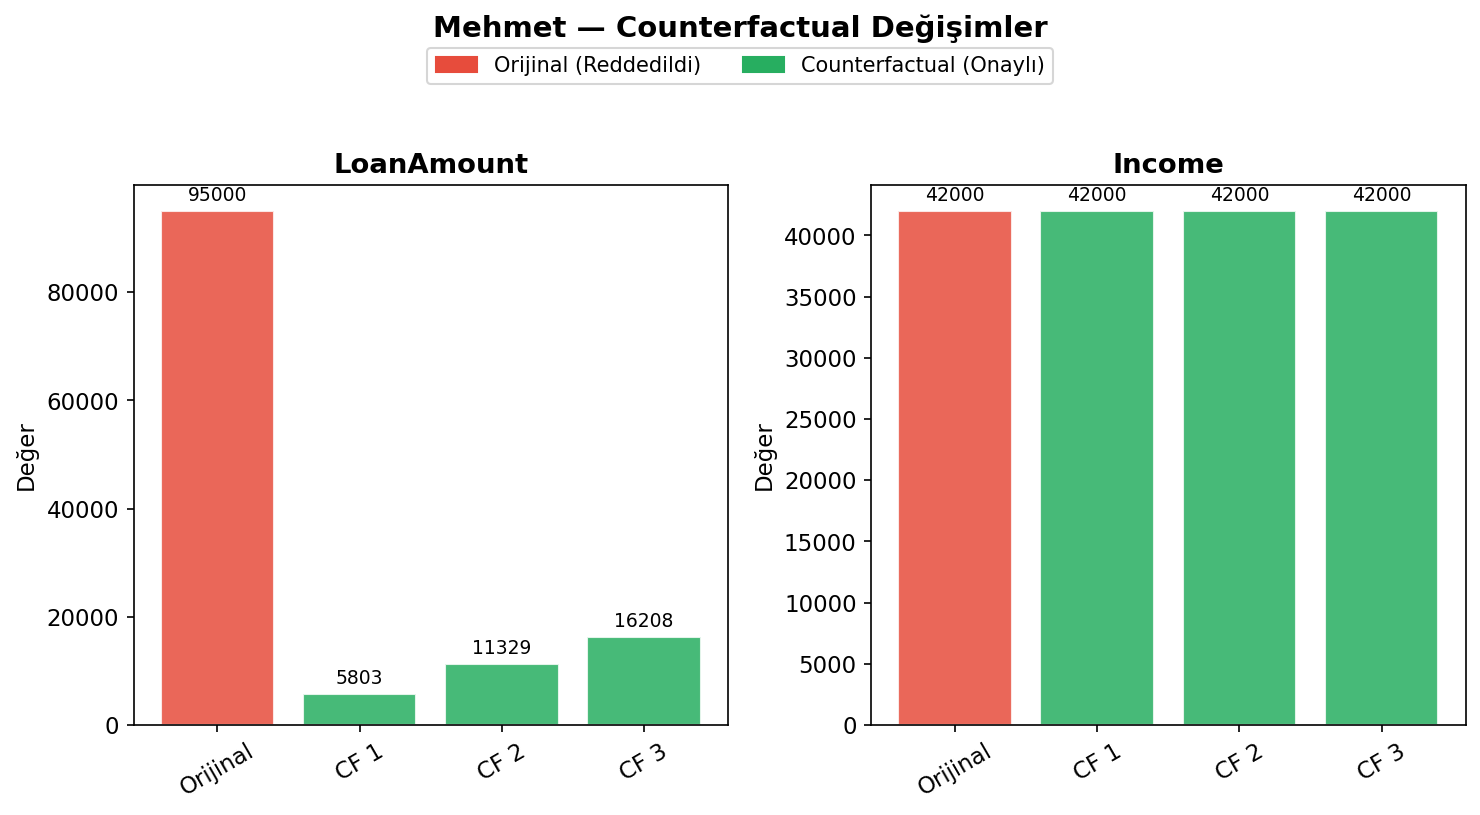

In [8]:
def plot_cf_changes(
    original: dict,
    cf_df: pd.DataFrame,
    name: str,
    features: list,
    save_path: Path = None,
) -> None:
    """Orijinal başvuru vs. counterfactual'ları bar grafik olarak karşılaştırır."""
    cf_df = cf_df.drop(columns=['Default'], errors='ignore').reset_index(drop=True)
    n_cf  = len(cf_df)
    n_feat = len(features)

    fig, axes = plt.subplots(1, n_feat, figsize=(5 * n_feat, 5))
    if n_feat == 1:
        axes = [axes]

    colors  = ['#e74c3c'] + ['#27ae60'] * n_cf
    labels  = ['Orijinal'] + [f'CF {i+1}' for i in range(n_cf)]
    values_list = [original] + [cf_df.iloc[i].to_dict() for i in range(n_cf)]

    for ax, feat in zip(axes, features):
        vals = [v.get(feat, 0) for v in values_list]
        bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white')
        ax.bar_label(bars, fmt='{:.0f}', padding=3, fontsize=9)
        ax.set_title(feat, fontweight='bold')
        ax.set_ylabel('Değer')
        ax.tick_params(axis='x', rotation=30)

    patches = [
        mpatches.Patch(color='#e74c3c', label='Orijinal (Reddedildi)'),
        mpatches.Patch(color='#27ae60', label='Counterfactual (Onaylı)'),
    ]
    fig.legend(handles=patches, loc='upper center', ncol=2,
               bbox_to_anchor=(0.5, 1.05), fontsize=10)
    fig.suptitle(f'{name} — Counterfactual Değişimler', fontsize=14, fontweight='bold', y=1.08)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Kaydedildi: {save_path.name}')
    plt.show()


# Grafik — Mehmet
cf1_df = cf1.cf_examples_list[0].final_cfs_df
if cf1_df is not None and not cf1_df.empty:
    plot_cf_changes(
        original  = mehmet,
        cf_df     = cf1_df,
        name      = 'Mehmet',
        features  = ['LoanAmount', 'Income'],
        save_path = FIG_DIR / 'dice_01_mehmet_changes.png',
    )
else:
    print('Mehmet için counterfactual bulunamadı.')

Kaydedildi: dice_02_ayse_changes.png


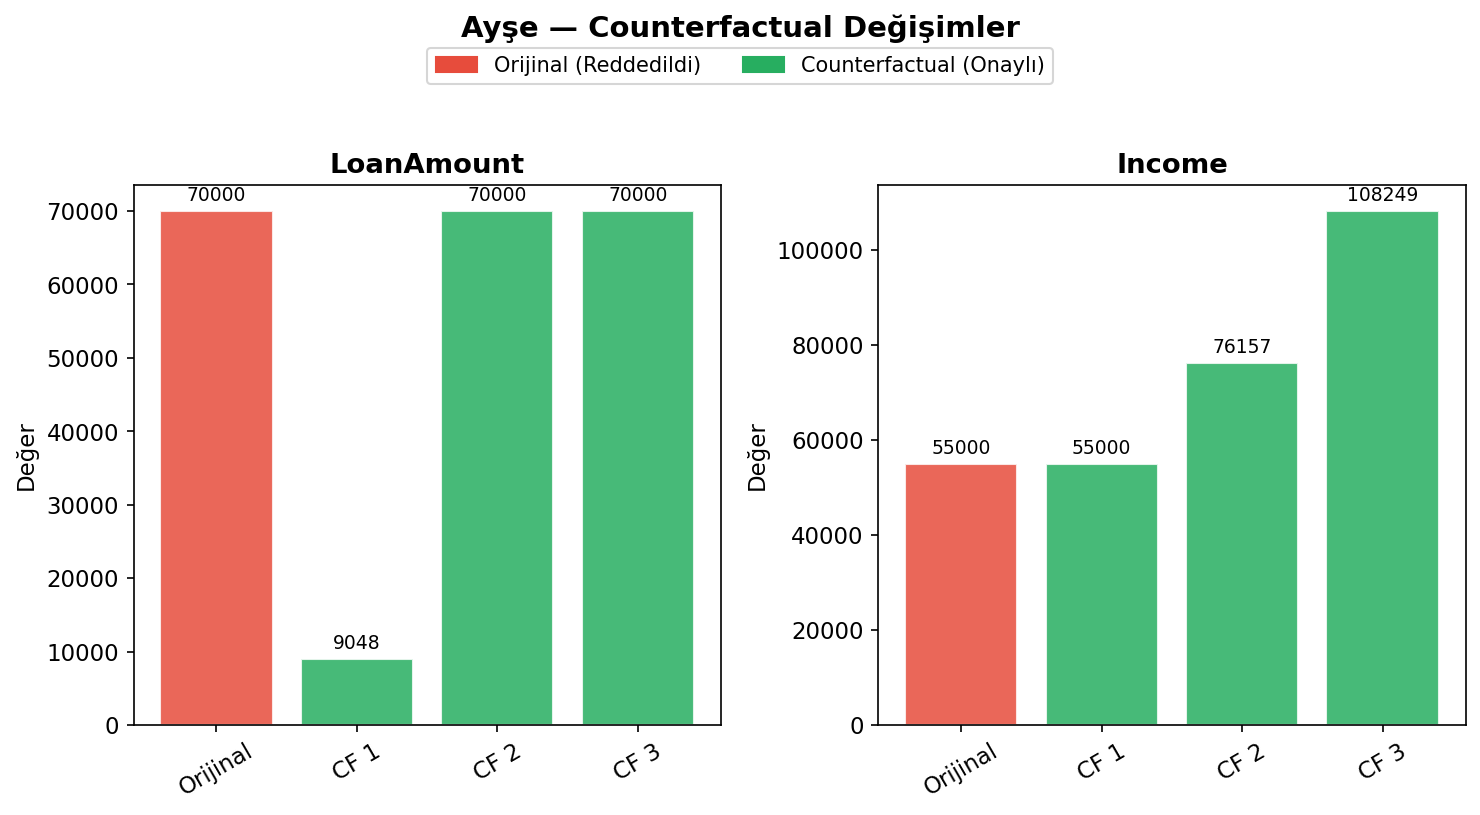

In [9]:
# Grafik — Ayşe
cf2_df = cf2.cf_examples_list[0].final_cfs_df
if cf2_df is not None and not cf2_df.empty:
    plot_cf_changes(
        original  = ayse,
        cf_df     = cf2_df,
        name      = 'Ayşe',
        features  = ['LoanAmount', 'Income'],
        save_path = FIG_DIR / 'dice_02_ayse_changes.png',
    )
else:
    print('Ayşe için counterfactual bulunamadı.')

## 8. API Kullanımı — Gerçek İnference Örneği

`src/explainability/dice_explainer.py` modülü, API entegrasyonu için tasarlandı.  
Aşağıdaki örnek, FastAPI endpoint'inin nasıl kullanacağını gösterir.

In [10]:
import sys
sys.path.insert(0, str(ROOT))

from src.explainability.dice_explainer import DiceExplainer

dice = DiceExplainer()

# Gerçek API'ye gelen ham veri (string kategorikler)
user_raw = {
    'Age': 38, 'Income': 42000, 'LoanAmount': 95000, 'CreditScore': 540,
    'MonthsEmployed': 24, 'NumCreditLines': 5, 'InterestRate': 18.5,
    'LoanTerm': 60, 'DTIRatio': 0.62,
    "Education": "Bachelor's", "EmploymentType": "Full-time",
    "MaritalStatus": "Single", "HasMortgage": "No",
    "HasDependents": "Yes", "LoanPurpose": "Home", "HasCoSigner": "No",
}

scenarios = dice.generate_counterfactuals(user_raw, n_cf=3)

print('DiCE Counterfactual Sonuçları:')
for i, s in enumerate(scenarios, 1):
    print(f'\nSenaryo {i}:')
    for feature, change in s['changes'].items():
        print(f'  {feature}: {change["from"]} → {change["to"]}')

100%|██████████| 1/1 [00:00<00:00,  3.47it/s]

DiCE Counterfactual Sonuçları:

Senaryo 1:
  LoanAmount: 95000.0 → 5803.0
  HasCoSigner: No → Yes

Senaryo 2:
  LoanAmount: 95000.0 → 11329.0
  HasCoSigner: No → Yes

Senaryo 3:
  LoanAmount: 95000.0 → 16208.0
  HasCoSigner: No → Yes


## 9. Özet

| Çıktı | Yer | Kullanım |
|-------|-----|----------|
| `dice_01_mehmet_changes.png` | `reports/figures/` | Örnek görsel |
| `dice_02_ayse_changes.png` | `reports/figures/` | Örnek görsel |
| `src/explainability/dice_explainer.py` | `src/` | API entegrasyonu |

**Actionable features:** `LoanAmount`, `HasCoSigner`, `Income`  
**Method:** DiCE random (herhangi bir model ile çalışır, gradient gerektirmez)  
**Background:** `data/interim/loans_cleaned.csv` — 5.000 satır örneklem  

**FastAPI entegrasyonu için:**
```python
from src.models.predictor import LoanGuardPredictor
from src.explainability.dice_explainer import DiceExplainer

predictor = LoanGuardPredictor()   # uygulama başlarken bir kez init et
dice      = DiceExplainer()        # uygulama başlarken bir kez init et

@app.post('/predict')
def predict(body: ApplicantSchema):
    result = predictor.predict(body.dict())
    if result['decision'] == 'rejected':
        result['counterfactuals'] = dice.generate_counterfactuals(body.dict())
    return result
```

**Sonraki adım:** `src/api/` — FastAPI route implementasyonu (backend mühendisi)